# Experiment 2: True LOGO ResNet-50 - Remaining Six Folds

Use this notebook after the `heldout_Midjourney` fold has already been completed.

Important setup:

```python
AI_GENERATORS = [
    "Midjourney",
    "stable_diffusion_v_1_5",
    "glide",
    "wukong",
    "BigGAN",
    "VQDM",
    "ADM",
]
```

Midjourney must stay in `AI_GENERATORS` because it should be used as seen training data when another generator is held out.

Only the remaining six folds should be run:

```python
RUN_FOLDS = [
    "stable_diffusion_v_1_5",
    "glide",
    "wukong",
    "BigGAN",
    "VQDM",
    "ADM",
]
```

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "kagglehub",
        "scikit-learn",
        "scipy",
        "pandas",
        "matplotlib",
    ],
    check=True,
)

import kagglehub
import tensorflow as tf

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# -----------------------------
# Output location
# -----------------------------

# Recommended first run: False.
# This keeps results in /content/experiment_2_logo in Colab or ./experiment_2_logo locally.
SAVE_RESULTS_TO_DRIVE = False

# Only used when SAVE_RESULTS_TO_DRIVE = True.
DRIVE_OUTPUT_DIR = Path("/content/drive/MyDrive/thesis_resnet50/experiment_2_logo")

# Optional. Do not enable unless you really want a second copy of the dataset.
COPY_DATASET_TO_OUTPUT_FOLDER = False

EXPECTED_DIRS = [
    "Nature",
    "Midjourney",
    "stable_diffusion_v_1_5",
    "glide",
    "wukong",
    "BigGAN",
    "VQDM",
    "ADM",
]


def has_expected_dirs(root):
    return root.exists() and all((root / name).exists() for name in EXPECTED_DIRS)


def find_genimage_root(root):
    root = Path(root)
    candidates = [root]
    candidates.extend([p for p in root.rglob("*") if p.is_dir()])
    for candidate in candidates:
        if has_expected_dirs(candidate):
            return candidate
    return None


print("Downloading/checking KaggleHub cache for cartografia/unbiased-tiny-genimage ...")
downloaded_path = Path(kagglehub.dataset_download("cartografia/unbiased-tiny-genimage"))
dataset_root = find_genimage_root(downloaded_path)

if dataset_root is None:
    print("KaggleHub returned:", downloaded_path)
    print("Folder preview:")
    for path in sorted(downloaded_path.rglob("*"))[:80]:
        print(path)
    raise FileNotFoundError("Could not find expected GenImage source folders inside KaggleHub download.")

if SAVE_RESULTS_TO_DRIVE:
    if not IN_COLAB:
        print("Not running in Colab, so Drive mount is unavailable. Falling back to local output.")
        output_dir = Path.cwd() / "experiment_2_logo"
    else:
        drive.mount("/content/drive")
        output_dir = DRIVE_OUTPUT_DIR
else:
    output_dir = Path("/content/experiment_2_logo") if Path("/content").exists() else Path.cwd() / "experiment_2_logo"

output_dir.mkdir(parents=True, exist_ok=True)

if COPY_DATASET_TO_OUTPUT_FOLDER:
    dataset_copy = output_dir / "dataset_copy"
    if not dataset_copy.exists():
        print("Copying dataset to:", dataset_copy)
        shutil.copytree(dataset_root, dataset_copy)
    dataset_root = dataset_copy

os.environ["GENIMAGE_BASE_DIR"] = str(dataset_root)
os.environ["THESIS_OUTPUT_DIR"] = str(output_dir)

print("Using GENIMAGE_BASE_DIR:", os.environ["GENIMAGE_BASE_DIR"])
print("Using THESIS_OUTPUT_DIR:", os.environ["THESIS_OUTPUT_DIR"])
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

Downloading/checking KaggleHub cache for cartografia/unbiased-tiny-genimage ...


100%|██████████| 2.35G/2.35G [00:41<00:00, 60.4MB/s]

Extracting files...


Using GENIMAGE_BASE_DIR: /root/.cache/kagglehub/datasets/cartografia/unbiased-tiny-genimage/versions/1
Using THESIS_OUTPUT_DIR: /content/experiment_2_logo
TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.optimize import minimize_scalar
from scipy.special import expit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [3]:
# -----------------------------
# Configuration
# -----------------------------

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

BASE_DIR = Path(os.environ.get("GENIMAGE_BASE_DIR", "./unbiased-tiny-genimage"))
OUTPUT_DIR = Path(os.environ.get("THESIS_OUTPUT_DIR", "./experiment_2_logo"))

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REAL_FOLDER = "Nature"
AI_GENERATORS = [
    "Midjourney",
    "stable_diffusion_v_1_5",
    "glide",
    "wukong",
    "BigGAN",
    "VQDM",
    "ADM",
]

# Midjourney has already been completed as a held-out fold.
# Keep Midjourney in AI_GENERATORS so it is used as seen training data
# when another generator is held out.
RUN_FOLDS = [
    "stable_diffusion_v_1_5",
    "glide",
    "wukong",
    "BigGAN",
    "VQDM",
    "ADM",
]

# To rerun all seven folds from scratch, use:
# RUN_FOLDS = AI_GENERATORS

# Balanced testing makes accuracy comparable across folds.
BALANCE_TEST_SET = True

WARMUP_EPOCHS = 2
FINETUNE_EPOCHS = 8
WARMUP_LR = 1e-3
FINETUNE_LR = 1e-5

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Output directory:", OUTPUT_DIR)

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"GenImage folder not found at {BASE_DIR}. "
        "Run the KaggleHub setup cell first."
    )

TensorFlow: 2.20.0
Output directory: /content/experiment_2_logo


In [4]:
# -----------------------------
# Dataset utilities
# -----------------------------

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}


def list_images(folder: Path):
    paths = []
    for path in folder.iterdir():
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            paths.append(str(path))
    return np.array(sorted(paths))


def load_inventory():
    inventory = {}
    inventory[REAL_FOLDER] = list_images(BASE_DIR / REAL_FOLDER)
    for generator in AI_GENERATORS:
        inventory[generator] = list_images(BASE_DIR / generator)
    return inventory


inventory = load_inventory()
for source, paths in inventory.items():
    print(f"{source:24s} {len(paths):6d}")

Nature                     5828
Midjourney                 2500
stable_diffusion_v_1_5     2500
glide                      2500
wukong                     2500
BigGAN                     2500
VQDM                       2500
ADM                        2500


In [5]:
# -----------------------------
# Split helpers
# -----------------------------


def split_real_paths(real_paths, seed=SEED):
    real_train, real_temp = train_test_split(
        real_paths,
        test_size=0.20,
        random_state=seed,
        shuffle=True,
    )
    real_val, real_test = train_test_split(
        real_temp,
        test_size=0.50,
        random_state=seed,
        shuffle=True,
    )
    return real_train, real_val, real_test


def split_seen_ai_paths(inventory, heldout_generator, seed=SEED):
    ai_train_parts = []
    ai_val_parts = []

    seen_generators = [g for g in AI_GENERATORS if g != heldout_generator]
    for generator in seen_generators:
        train_g, val_g = train_test_split(
            inventory[generator],
            test_size=0.10,
            random_state=seed,
            shuffle=True,
        )
        ai_train_parts.append(train_g)
        ai_val_parts.append(val_g)

    ai_train = np.concatenate(ai_train_parts)
    ai_val = np.concatenate(ai_val_parts)
    return ai_train, ai_val, seen_generators


def sample_heldout_ai_for_test(heldout_paths, n_real_test, seed=SEED):
    if not BALANCE_TEST_SET:
        return heldout_paths
    n = min(n_real_test, len(heldout_paths))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(heldout_paths), size=n, replace=False)
    return heldout_paths[idx]


def make_fold_arrays(heldout_generator):
    real_train, real_val, real_test = split_real_paths(inventory[REAL_FOLDER])
    ai_train, ai_val, seen_generators = split_seen_ai_paths(
        inventory,
        heldout_generator,
    )
    heldout_ai_test = sample_heldout_ai_for_test(
        inventory[heldout_generator],
        n_real_test=len(real_test),
    )

    train_paths = np.concatenate([real_train, ai_train])
    train_labels = np.concatenate([
        np.zeros(len(real_train), dtype=np.int32),
        np.ones(len(ai_train), dtype=np.int32),
    ])

    val_paths = np.concatenate([real_val, ai_val])
    val_labels = np.concatenate([
        np.zeros(len(real_val), dtype=np.int32),
        np.ones(len(ai_val), dtype=np.int32),
    ])

    test_paths = np.concatenate([real_test, heldout_ai_test])
    test_labels = np.concatenate([
        np.zeros(len(real_test), dtype=np.int32),
        np.ones(len(heldout_ai_test), dtype=np.int32),
    ])

    test_sources = np.concatenate([
        np.array([REAL_FOLDER] * len(real_test)),
        np.array([heldout_generator] * len(heldout_ai_test)),
    ])

    return {
        "heldout_generator": heldout_generator,
        "seen_generators": seen_generators,
        "train_paths": train_paths,
        "train_labels": train_labels,
        "val_paths": val_paths,
        "val_labels": val_labels,
        "test_paths": test_paths,
        "test_labels": test_labels,
        "test_sources": test_sources,
    }


def describe_fold(fold):
    print("\nFold:", fold["heldout_generator"])
    print("Seen AI generators:", ", ".join(fold["seen_generators"]))
    for split in ["train", "val", "test"]:
        labels = fold[f"{split}_labels"]
        print(
            f"{split:5s}: {len(labels):6d} | "
            f"real={np.sum(labels == 0):5d} | ai={np.sum(labels == 1):5d}"
        )


example_fold = make_fold_arrays(RUN_FOLDS[0])
describe_fold(example_fold)


Fold: Midjourney
Seen AI generators: stable_diffusion_v_1_5, glide, wukong, BigGAN, VQDM, ADM
train:  18162 | real= 4662 | ai=13500
val  :   2083 | real=  583 | ai= 1500
test :   1166 | real=  583 | ai=  583


In [6]:
# -----------------------------
# tf.data pipeline
# -----------------------------


def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    return image, label


def augment_image(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.10)
    image = tf.image.random_contrast(image, lower=0.90, upper=1.10)
    return image, label


def resnet_preprocess(image, label):
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label


def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=min(len(paths), 4096), seed=SEED)
    ds = ds.map(decode_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(resnet_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


def get_class_weight(labels):
    labels = np.asarray(labels)
    total = len(labels)
    n_real = np.sum(labels == 0)
    n_ai = np.sum(labels == 1)
    return {
        0: total / (2.0 * n_real),
        1: total / (2.0 * n_ai),
    }

In [7]:
# -----------------------------
# Model
# -----------------------------


def build_resnet50_logits_model():
    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.20)(x)
    logits = tf.keras.layers.Dense(1, activation=None, name="logit")(x)

    model = tf.keras.Model(inputs=inputs, outputs=logits)
    return model, base_model


def compile_logits_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(threshold=0.0, name="accuracy"),
        ],
    )


def make_callbacks(fold_dir):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(str(fold_dir / "training_log.csv")),
    ]

In [8]:
# -----------------------------
# Calibration and metrics
# -----------------------------


def collect_logits(model, ds):
    logits = model.predict(ds, verbose=1).reshape(-1)
    return logits


def compute_confidence_ece(y_true, probs, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs)
    pred = (probs >= 0.5).astype(int)
    confidence = np.maximum(probs, 1.0 - probs)
    correct = (pred == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidence >= bins[i]) & (confidence <= bins[i + 1])
        else:
            mask = (confidence >= bins[i]) & (confidence < bins[i + 1])
        if np.any(mask):
            bin_acc = correct[mask].mean()
            bin_conf = confidence[mask].mean()
            ece += (mask.sum() / len(y_true)) * abs(bin_acc - bin_conf)
    return float(ece)


def fit_temperature_nll(val_logits, val_labels):
    val_labels = np.asarray(val_labels).astype(int)

    def objective(temp):
        probs = expit(val_logits / temp)
        return log_loss(val_labels, probs, labels=[0, 1])

    result = minimize_scalar(
        objective,
        method="bounded",
        bounds=(0.05, 10.0),
        options={"xatol": 1e-4},
    )
    return float(result.x), float(result.fun)


def compute_metrics(y_true, probs, prefix=""):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs)
    pred = (probs >= 0.5).astype(int)
    confidence = np.maximum(probs, 1.0 - probs)
    correct = pred == y_true
    wrong = ~correct

    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    metrics = {
        f"{prefix}accuracy": float(accuracy_score(y_true, pred)),
        f"{prefix}balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        f"{prefix}auroc": float(roc_auc_score(y_true, probs)),
        f"{prefix}log_loss": float(log_loss(y_true, probs, labels=[0, 1])),
        f"{prefix}brier": float(brier_score_loss(y_true, probs)),
        f"{prefix}ece": compute_confidence_ece(y_true, probs, n_bins=10),
        f"{prefix}avg_confidence": float(confidence.mean()),
        f"{prefix}avg_conf_correct": float(confidence[correct].mean()) if np.any(correct) else np.nan,
        f"{prefix}avg_conf_wrong": float(confidence[wrong].mean()) if np.any(wrong) else np.nan,
        f"{prefix}high_conf_total": int(np.sum(confidence > 0.90)),
        f"{prefix}high_conf_errors": int(np.sum((confidence > 0.90) & wrong)),
        f"{prefix}tn": int(tn),
        f"{prefix}fp": int(fp),
        f"{prefix}fn": int(fn),
        f"{prefix}tp": int(tp),
    }
    if metrics[f"{prefix}high_conf_total"] > 0:
        metrics[f"{prefix}high_conf_error_rate"] = (
            metrics[f"{prefix}high_conf_errors"] / metrics[f"{prefix}high_conf_total"]
        )
    else:
        metrics[f"{prefix}high_conf_error_rate"] = 0.0
    return metrics


def save_predictions(fold_dir, fold, logits, probs, probs_calibrated):
    y_true = fold["test_labels"]
    pred = (probs >= 0.5).astype(int)
    pred_cal = (probs_calibrated >= 0.5).astype(int)

    df = pd.DataFrame({
        "path": fold["test_paths"],
        "source": fold["test_sources"],
        "label": y_true,
        "logit": logits,
        "prob_ai": probs,
        "prob_ai_calibrated": probs_calibrated,
        "prediction": pred,
        "prediction_calibrated": pred_cal,
        "confidence": np.maximum(probs, 1.0 - probs),
        "confidence_calibrated": np.maximum(probs_calibrated, 1.0 - probs_calibrated),
        "correct": pred == y_true,
        "correct_calibrated": pred_cal == y_true,
    })
    out_path = fold_dir / "test_predictions.csv"
    df.to_csv(out_path, index=False)
    return df

In [9]:
# -----------------------------
# Visualization helpers
# -----------------------------


def plot_reliability(ax, y_true, probs, title, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs)
    pred = (probs >= 0.5).astype(int)
    confidence = np.maximum(probs, 1.0 - probs)
    correct = (pred == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    xs = []
    ys = []
    sizes = []
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (confidence >= bins[i]) & (confidence <= bins[i + 1])
        else:
            mask = (confidence >= bins[i]) & (confidence < bins[i + 1])
        if np.any(mask):
            xs.append(confidence[mask].mean())
            ys.append(correct[mask].mean())
            sizes.append(mask.sum())

    ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    ax.scatter(xs, ys, s=np.maximum(20, np.array(sizes) / max(sizes) * 200), alpha=0.75)
    ax.plot(xs, ys, linewidth=1.5)
    ax.set_xlim(0.45, 1.01)
    ax.set_ylim(0.45, 1.01)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(alpha=0.25)


def plot_fold_calibration(fold_dir, y_true, probs, probs_calibrated, heldout_generator):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plot_reliability(axes[0], y_true, probs, "Before temperature scaling")
    plot_reliability(axes[1], y_true, probs_calibrated, "After temperature scaling")
    fig.suptitle(f"LOGO held-out generator: {heldout_generator}", fontweight="bold")
    fig.tight_layout()
    fig.savefig(fold_dir / "reliability_before_after.png", dpi=200, bbox_inches="tight")
    plt.show()


def plot_confidence_histogram(fold_dir, y_true, probs, probs_calibrated, heldout_generator):
    y_true = np.asarray(y_true).astype(int)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, p, title in [
        (axes[0], probs, "Before temperature scaling"),
        (axes[1], probs_calibrated, "After temperature scaling"),
    ]:
        pred = (p >= 0.5).astype(int)
        conf = np.maximum(p, 1.0 - p)
        correct = pred == y_true
        ax.hist(conf[correct], bins=20, alpha=0.65, label=f"Correct (n={correct.sum()})")
        ax.hist(conf[~correct], bins=20, alpha=0.65, label=f"Wrong (n={(~correct).sum()})")
        ax.axvline(0.90, color="black", linestyle="--", linewidth=1, label="0.90 threshold")
        ax.set_xlim(0.5, 1.0)
        ax.set_xlabel("Confidence")
        ax.set_ylabel("Count")
        ax.set_title(title)
        ax.legend(fontsize=8)

    fig.suptitle(f"Confidence distribution: {heldout_generator}", fontweight="bold")
    fig.tight_layout()
    fig.savefig(fold_dir / "confidence_histogram_before_after.png", dpi=200, bbox_inches="tight")
    plt.show()

In [10]:
# -----------------------------
# Run one LOGO fold
# -----------------------------


def run_logo_fold(heldout_generator):
    fold = make_fold_arrays(heldout_generator)
    describe_fold(fold)

    fold_dir = OUTPUT_DIR / f"heldout_{heldout_generator}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    with open(fold_dir / "fold_config.json", "w") as f:
        json.dump({
            "heldout_generator": heldout_generator,
            "seen_generators": fold["seen_generators"],
            "balance_test_set": BALANCE_TEST_SET,
            "seed": SEED,
            "img_size": IMG_SIZE,
            "batch_size": BATCH_SIZE,
        }, f, indent=2)

    train_ds = make_dataset(fold["train_paths"], fold["train_labels"], training=True)
    val_ds = make_dataset(fold["val_paths"], fold["val_labels"], training=False)
    test_ds = make_dataset(fold["test_paths"], fold["test_labels"], training=False)

    class_weight = get_class_weight(fold["train_labels"])
    print("Class weights:", class_weight)

    model, base_model = build_resnet50_logits_model()

    print("\nWarmup: train classification head")
    compile_logits_model(model, learning_rate=WARMUP_LR)
    history_warmup = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=WARMUP_EPOCHS,
        class_weight=class_weight,
        callbacks=make_callbacks(fold_dir),
        verbose=1,
    )

    print("\nFine-tuning: unfreeze ResNet-50")
    base_model.trainable = True
    compile_logits_model(model, learning_rate=FINETUNE_LR)
    history_finetune = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINETUNE_EPOCHS,
        class_weight=class_weight,
        callbacks=make_callbacks(fold_dir),
        verbose=1,
    )

    model_path = fold_dir / "resnet50_logo_logits.keras"
    model.save(model_path)
    print("Saved model:", model_path)

    print("\nCollecting validation logits for temperature scaling")
    val_logits = collect_logits(model, val_ds)
    temperature, val_nll = fit_temperature_nll(val_logits, fold["val_labels"])
    print(f"Optimal temperature: {temperature:.4f} | validation NLL: {val_nll:.4f}")

    print("\nCollecting test logits")
    test_logits = collect_logits(model, test_ds)
    probs = expit(test_logits)
    probs_calibrated = expit(test_logits / temperature)

    before = compute_metrics(fold["test_labels"], probs, prefix="before_")
    after = compute_metrics(fold["test_labels"], probs_calibrated, prefix="after_")

    result = {
        "heldout_generator": heldout_generator,
        "seen_generators": "|".join(fold["seen_generators"]),
        "temperature": temperature,
        "val_nll_at_temperature": val_nll,
        "train_n": int(len(fold["train_labels"])),
        "val_n": int(len(fold["val_labels"])),
        "test_n": int(len(fold["test_labels"])),
        "test_real_n": int(np.sum(fold["test_labels"] == 0)),
        "test_ai_n": int(np.sum(fold["test_labels"] == 1)),
        **before,
        **after,
    }

    with open(fold_dir / "metrics.json", "w") as f:
        json.dump(result, f, indent=2)

    predictions_df = save_predictions(
        fold_dir,
        fold,
        logits=test_logits,
        probs=probs,
        probs_calibrated=probs_calibrated,
    )

    plot_fold_calibration(
        fold_dir,
        fold["test_labels"],
        probs,
        probs_calibrated,
        heldout_generator,
    )
    plot_confidence_histogram(
        fold_dir,
        fold["test_labels"],
        probs,
        probs_calibrated,
        heldout_generator,
    )

    print("\nFold result:")
    print(pd.Series(result))
    return result, predictions_df


Fold: Midjourney
Seen AI generators: stable_diffusion_v_1_5, glide, wukong, BigGAN, VQDM, ADM
train:  18162 | real= 4662 | ai=13500
val  :   2083 | real=  583 | ai= 1500
test :   1166 | real=  583 | ai=  583
Class weights: {0: np.float64(1.9478764478764479), 1: np.float64(0.6726666666666666)}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Warmup: train classification head
Epoch 1/2
568/568 ━━━━━━━━━━━━━━━━━━━━ 109s 148ms/step - accuracy: 0.9247 - loss: 0.1998 - val_accuracy: 0.9155 - val_loss: 0.2165 - learning_rate: 0.0010
Epoch 2/2
568/568 ━━━━━━━━━━━━━━━━━━━━ 119s 124ms/step - accuracy: 0.9503 - loss: 0.1475 - val_accuracy: 0.9275 - val_loss: 0.2054 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.

Fine-tuning: unfreeze ResNet-50
Epoch 1/8
568/568 ━━━━━━━━━━━━━━━━━━━━ 268s 362ms/step - accuracy: 0.8845 - loss: 0.4493 - val_accuracy: 0.9323 - val_loss: 0.1761 - learning_rate: 1.0000e-05
Epoch 2/8
568/568 ━━━━━━━━━━━━━━━━━━━━ 176s 310ms/step - a

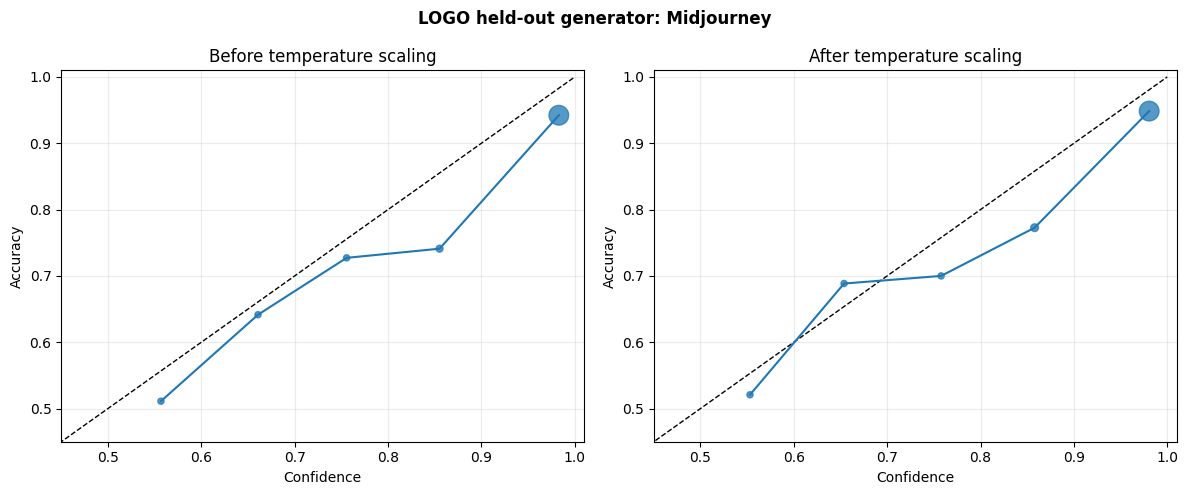

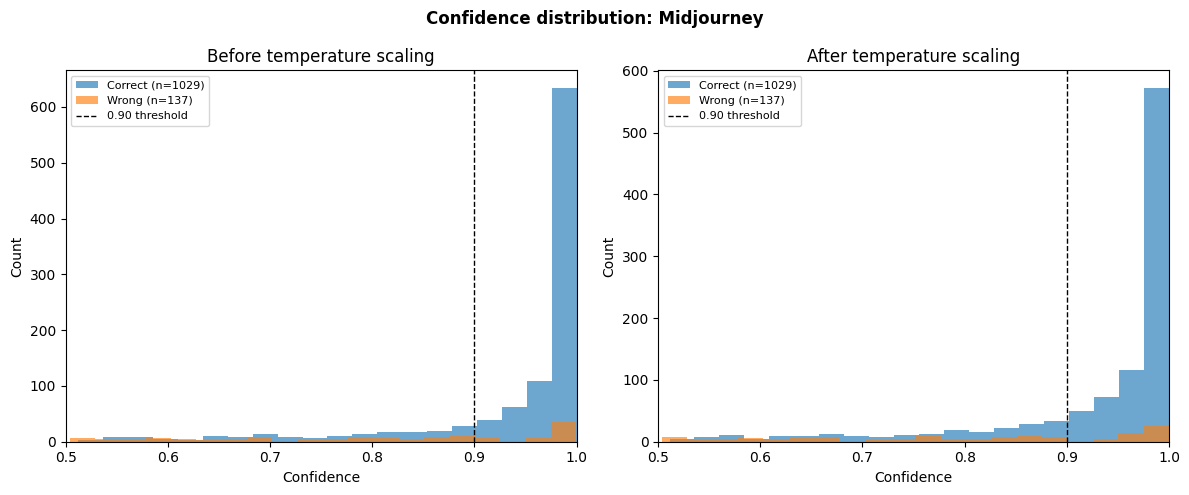


Fold result:
heldout_generator                                                     Midjourney
seen_generators                stable_diffusion_v_1_5|glide|wukong|BigGAN|VQD...
temperature                                                             1.129794
val_nll_at_temperature                                                  0.082071
train_n                                                                    18162
val_n                                                                       2083
test_n                                                                      1166
test_real_n                                                                  583
test_ai_n                                                                    583
before_accuracy                                                         0.882504
before_balanced_accuracy                                                0.882504
before_auroc                                                            0.940825
before_log_los

,heldout_generator,seen_generators,temperature,val_nll_at_temperature,train_n,val_n,test_n,test_real_n,test_ai_n,before_accuracy,...,after_avg_confidence,after_avg_conf_correct,after_avg_conf_wrong,after_high_conf_total,after_high_conf_errors,after_tn,after_fp,after_fn,after_tp,after_high_conf_error_rate
0,Midjourney,stable_diffusion_v_1_5|glide|wukong|BigGAN|VQD...,1.129794,0.082071,18162,2083,1166,583,583,0.882504,...,0.918708,0.93469,0.798666,855,44,515,68,69,514,0.051462


In [11]:
# -----------------------------
# Run selected folds
# -----------------------------

all_results = []

for heldout in RUN_FOLDS:
    result, _ = run_logo_fold(heldout)
    all_results.append(result)

summary_df = pd.DataFrame(all_results)
summary_path = OUTPUT_DIR / "logo_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\nSaved summary:", summary_path)
display(summary_df)

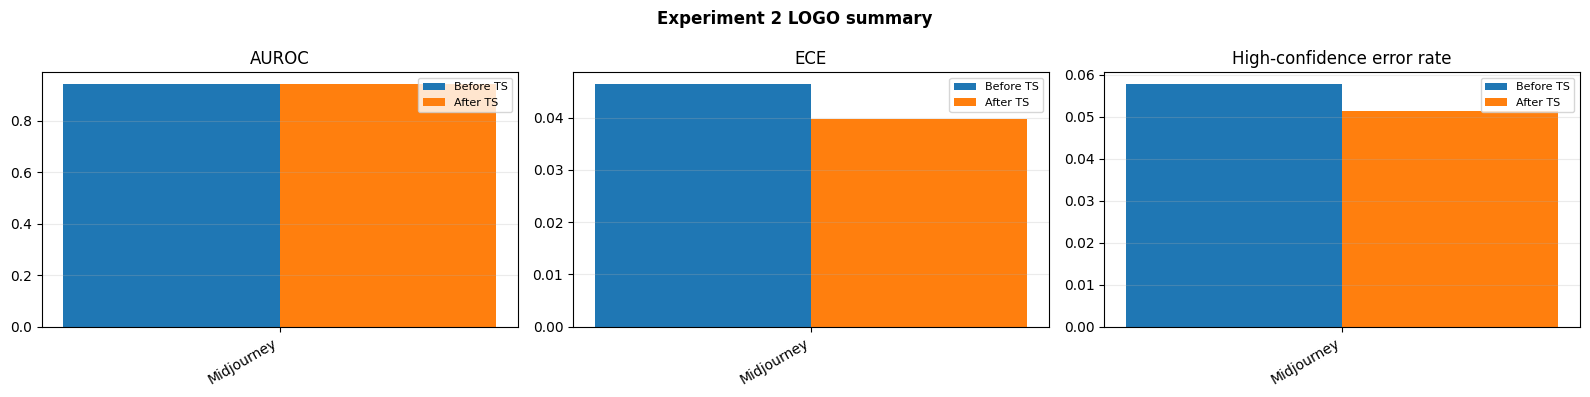

In [12]:
# -----------------------------
# Summary plot for completed folds
# -----------------------------

if len(summary_df) > 0:
    metrics_to_plot = [
        ("before_auroc", "after_auroc", "AUROC"),
        ("before_ece", "after_ece", "ECE"),
        (
            "before_high_conf_error_rate",
            "after_high_conf_error_rate",
            "High-confidence error rate",
        ),
    ]

    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4))
    if len(metrics_to_plot) == 1:
        axes = [axes]

    x = np.arange(len(summary_df))
    width = 0.35
    labels = summary_df["heldout_generator"].tolist()

    for ax, (before_col, after_col, title) in zip(axes, metrics_to_plot):
        ax.bar(x - width / 2, summary_df[before_col], width, label="Before TS")
        ax.bar(x + width / 2, summary_df[after_col], width, label="After TS")
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(fontsize=8)

    fig.suptitle("Experiment 2 LOGO summary", fontweight="bold")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "logo_summary_plot.png", dpi=200, bbox_inches="tight")
    plt.show()

## Package Results

        Run this after the experiment finishes. It creates one zip containing metrics, predictions, plots, and saved fold models.

In [13]:
from pathlib import Path
import os
import shutil

output_dir = Path(os.environ.get("THESIS_OUTPUT_DIR", "./experiment_2_logo"))
zip_base = output_dir.parent / f"{output_dir.name}_results"

if output_dir.exists():
    zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=output_dir)
    print("Created result zip:", zip_path)
else:
    print("Output directory not found yet:", output_dir)

Created result zip: /content/experiment_2_logo_results.zip
